In [35]:
# Data Manipulation Imports
import numpy as np
import pandas as pd
import xarray as xr
import scipy

# Plotting Imports
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

from datetime import datetime, date, time, timedelta
import matplotlib.dates as mdates

import zack_functions as zf

In [8]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '../../MHW_list.csv'

dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# Choose a HW
hw = "NA 2023"

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 

date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

In [9]:
%%time

# Parameters
columns = ('PRES','TEMP','PSAL','DOXY','CHLA','BBP700','LATITUDE','LONGITUDE','JULD','CYCLE_NUMBER','DB_NAME','PLATFORM_NUMBER')


# without DB_NAME you also would get any Spray glider or shipboard GLODAP data too
filters = [
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("JULD",">",date0), ("JULD","<",date1),
    ("DB_NAME","=","ARGO") 
]

df = pd.read_parquet(parquet_dir,columns=columns,filters=filters)
df = df.dropna(subset=['DOXY','CHLA','BBP700','PSAL','TEMP'])
df

In [10]:
df = df[df.PRES <= 300]
df = df[df.CHLA >= 0]

In [11]:
var_names = ['PRES','TEMP','PSAL','DOXY','CHLA','BBP700','LATITUDE','LONGITUDE','JULD']
PRES, TEMP, PSAL, DOXY, CHLA, BBP700, LATITUDE, LONGITUDE, JULD = var_names

In [12]:
data_da = df.set_index(JULD).resample('W').mean(numeric_only=True).dropna(how='all').reset_index()
peaks, _ = scipy.signal.find_peaks(data_da[CHLA], distance = 300/7)
full_bloom_slices = []
bloom_slices = []
for peak in peaks:
    bloom_slice = data_da[data_da[JULD].between(data_da[JULD].iloc[peak] - pd.Timedelta(weeks=4*6), data_da[JULD].iloc[peak] + pd.Timedelta(weeks=4*6))]
    bloom_slices.append(bloom_slice)
    full_bloom_slices.append(df[df[JULD].between(data_da[JULD].iloc[peak] - pd.Timedelta(weeks=4*6), data_da[JULD].iloc[peak] + pd.Timedelta(weeks=4*6))])
    

In [25]:
i = 0
for bloom_slice in bloom_slices:
    phenology_dict = zf.find_bloom_phenological_indices(bloom_slices[0], var_names)
    p_df = pd.DataFrame([phenology_dict]).reset_index(drop=True)
    if i == 0:
        phenology_df = pd.DataFrame([phenology_dict]).reset_index(drop=True)
    else:
        phenology_df = pd.concat([phenology_df, p_df])
    i += 1

TypeError: 'NoneType' object is not subscriptable

17

NameError: name 'bloom_max_value' is not defined

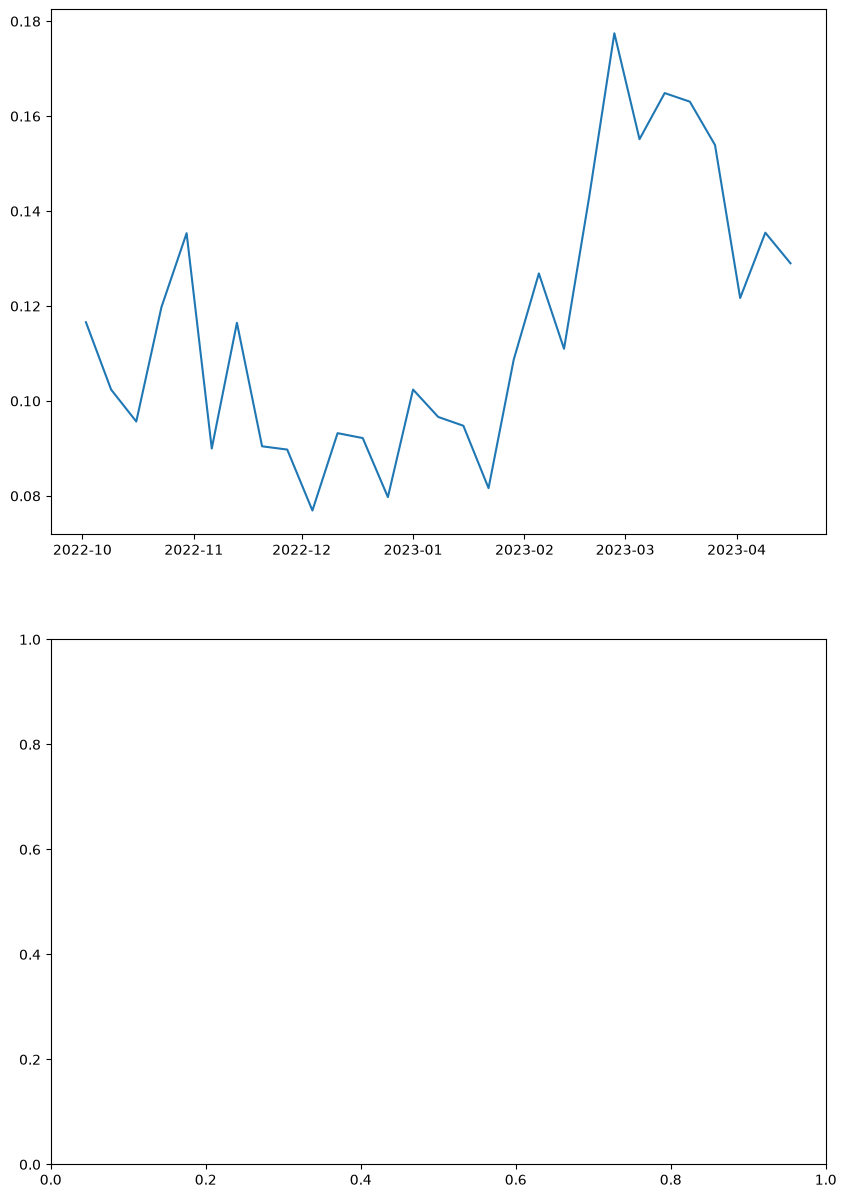

In [97]:
i = 0
for bloom_slice in bloom_slices:
    full_slice = full_bloom_slices[i].dropna(subset=[PRES])
    full_slice = full_slice.dropna(subset=[CHLA])
    x = mdates.date2num(full_slice["JULD"].to_numpy())
    y = full_slice[PRES].values.to_numpy()
    z = full_slice[CHLA].values.to_numpy()
    
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    X, Y = np.meshgrid(xi, yi)
    Z = scipy.interpolate.griddata((x, y), z, (X, Y), method='cubic')
    fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 15))
    
    ax1.plot(bloom_slice[JULD], bloom_slice[CHLA])
    
    for peak in peaks:
        if bloom_slice[CHLA].iloc[peak] == bloom_max_value:
            ax1.scatter(bloom_slice[JULD].iloc[peak], bloom_slice[CHLA].iloc[peak], color='red', marker='*', label='Main Peak')
        else:
            ax1.scatter(bloom_slice[JULD].iloc[peak], bloom_slice[CHLA].iloc[peak], color='red', marker='o')
    # for valley in valleys:
    try:
        ax1.scatter(bloom_initiation_TS[JULD], bloom_initiation_TS[CHLA], color='green', marker='o', label='Bloom Initiation (TS)')
    except TypeError:
        pass
    try:
        ax1.scatter(bloom_termination_TS[JULD], bloom_termination_TS[CHLA], color='orange', marker='o', label='Bloom Termination (TS)')
    except TypeError:
        pass
    try:
        ax1.scatter(bloom_initiation_CS[JULD], bloom_initiation_CS[CHLA], color='green', marker='x', label='Bloom Initiation (CS)')
    except TypeError:
        pass
    try:
        ax1.scatter(bloom_termination_CS[JULD], bloom_termination_CS[CHLA], color='orange', marker='x', label='Bloom Termination (CS)')
    except TypeError:
        pass
    try:
        ax1.scatter(bloom_initiation_RC[JULD], bloom_initiation_RC[CHLA], color='green', marker='s', label='Bloom Initiation (RC)')
    except TypeError:
        pass
    try:
        ax1.scatter(bloom_termination_RC[JULD], bloom_termination_RC[CHLA], color='orange', marker='s', label='Bloom Termination (RC)')
    except TypeError:
        pass
    ax1.axvline(bloom_slice["JULD"].loc[bloom_min], color='blue', linestyle='--', label='Pre-Bloom Minimum')
    ax1.axhline(0, color='gray', linestyle='--', label='Zero Line')
    ax1.set_xlabel("Date")
    ax1.set_xlim(full_slice["JULD"].min(), full_slice["JULD"].max())
    ax1.set_ylabel("Chlorophyll-a (mg/m^3)")
    ax1.legend()
    # ax1.set_title(f"Region {region} {round_to_year(bloom_slice['JULD'].loc[bloom_max]).year} - Bloom Phenology")
    # plt.tight_layout()
    # plt.savefig(f"region_{region}_{round_to_year(bloom_slice['JULD'].loc[bloom_max]).year}.png")
    # plt.show()
    
    # pc = ax2.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', vmin=0)
    pc = ax2.scatter(full_bloom_slices[i][JULD], full_bloom_slices[i][PRES], c=full_bloom_slices[i]["CHLA_ADJUSTED_BGCArgoPlus"], s=5)
    # 3. Format the x-axis
    # hfmt = mdates.DateFormatter('%Y-%m-%d')
    # ax2.xaxis.set_major_formatter(hfmt)
    
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Pressure (dbar)")
    # ax2.set_title(f"Region {region} {round_to_year(bloom_slice['JULD'].loc[bloom_max]).year} - Bloom Phenology Depth Profile")
    fig.colorbar(pc, label="Chlorophyll-a (mg/m^3)", orientation="horizontal")
    
    ax2.set_ylim(0, 400)
    ax2.invert_yaxis()
    plt.tight_layout()
    plt.show()
    i += 1


np.float64(43.51511937379837)

In [47]:
bloom_slice[CHLA].values

<ArrowExtensionArray>
[ 0.0874163880944252, 0.09077063947916031,  0.0785784050822258,
 0.08966858685016632, 0.08818080276250839,  0.0841909646987915,
  0.0739041417837143, 0.09802436083555222, 0.11440996080636978,
 0.10012900084257126, 0.12369448691606522, 0.15356558561325073,
 0.13987606763839722, 0.14948897063732147,   0.159070685505867,
  0.1420959234237671, 0.11355237662792206, 0.13260747492313385,
 0.12265510857105255, 0.13993112742900848,  0.1448608934879303,
  0.1738366037607193, 0.17936627566814423, 0.15195855498313904,
 0.21510180830955505, 0.15391238033771515,  0.1421639621257782,
 0.13626892864704132, 0.16277560591697693, 0.15520720183849335,
 0.13973069190979004, 0.11960747092962265, 0.12612421810626984,
 0.13911958038806915,  0.1417875587940216,  0.1366620808839798,
 0.12127327173948288, 0.12874948978424072, 0.12906529009342194,
 0.16122294962406158, 0.11905761063098907, 0.18598340451717377,
 0.11200350522994995,  0.1107197254896164, 0.10722614824771881,
 0.118425667285919

10    19337.0
11    19344.0
12    19351.0
13    19358.0
14    19365.0
15    19372.0
16    19379.0
17    19386.0
18    19393.0
19    19400.0
20    19407.0
21    19414.0
22    19421.0
23    19428.0
24    19435.0
25    19442.0
26    19449.0
27    19456.0
28    19463.0
29    19470.0
30    19477.0
31    19484.0
32    19491.0
33    19498.0
34    19505.0
35    19512.0
36    19519.0
37    19526.0
38    19533.0
39    19540.0
40    19547.0
41    19554.0
42    19561.0
43    19568.0
44    19575.0
45    19582.0
46    19589.0
47    19596.0
48    19603.0
49    19610.0
50    19617.0
51    19624.0
52    19631.0
53    19638.0
54    19645.0
55    19652.0
56    19659.0
57    19666.0
58    19673.0
Name: JULD, dtype: float64

In [50]:
bloom_slice[JULD]

10    2022-12-11 00:00:00
11    2022-12-18 00:00:00
12    2022-12-25 00:00:00
13    2023-01-01 00:00:00
14    2023-01-08 00:00:00
15    2023-01-15 00:00:00
16    2023-01-22 00:00:00
17    2023-01-29 00:00:00
18    2023-02-05 00:00:00
19    2023-02-12 00:00:00
20    2023-02-19 00:00:00
21    2023-02-26 00:00:00
22    2023-03-05 00:00:00
23    2023-03-12 00:00:00
24    2023-03-19 00:00:00
25    2023-03-26 00:00:00
26    2023-04-02 00:00:00
27    2023-04-09 00:00:00
28    2023-04-16 00:00:00
29    2023-04-23 00:00:00
30    2023-04-30 00:00:00
31    2023-05-07 00:00:00
32    2023-05-14 00:00:00
33    2023-05-21 00:00:00
34    2023-05-28 00:00:00
35    2023-06-04 00:00:00
36    2023-06-11 00:00:00
37    2023-06-18 00:00:00
38    2023-06-25 00:00:00
39    2023-07-02 00:00:00
40    2023-07-09 00:00:00
41    2023-07-16 00:00:00
42    2023-07-23 00:00:00
43    2023-07-30 00:00:00
44    2023-08-06 00:00:00
45    2023-08-13 00:00:00
46    2023-08-20 00:00:00
47    2023-08-27 00:00:00
48    2023-0